# Spoken Language Processing - Instituto Superior Técnico
### Laboratory Assignment 2 - Automatic Age Estimation Challenge
<!--[image](imgs/lab2_slp_banner.png)-->
<img src="imgs/lab2_slp_banner.png" alt="drawing" width="400"/>

# WEEK 1 - Classical models based on conventional knowledge-based features

This notebook contains the guide and code cells (some of them partially incomplete) that permit implementing two baseline systems for gender classification based on:
* frame based features and a simple generative model. 
* segment based features and a simple discriminative model.

Besides, the notebook will show how to obtain predictions and  score the systems on the development set. 

By the end of this week, students must adapt the last baseline to perform age regression.

**Read carefully the Markdown information, but also the comments inside the code cells (they provide useful information and hints), and also the code itself. The better you understand it, the easier will be modyfing it.**

## Before starting

Like in the introduction Notebook, we'll import the dummy Exception class:

In [2]:
from pf_tools import CheckThisCell

And  you need to mount Google drive if you are working on Google Colab. If you are not using Google Colab, skip or delete the following code cell:

And set-up your working directory:

In [3]:
import os

CWD = os.getcwd() 
DATADIR = os.path.abspath(os.path.join(CWD, '..', 'data'))

# Create the data directory if it doesn't exist
if not os.path.isdir(DATADIR):
    os.makedirs(DATADIR)
    print(f"Created directory: {DATADIR}")

print(f'Current working directory is set to: {CWD}')   
print(f'Your LAB2 data folder is: {DATADIR}')

Current working directory is set to: /home/luispma/slp_lab2/src
Your LAB2 data folder is: /home/luispma/slp_lab2/data


## 1. The MFCC and GMM baseline system 
This baseline consists of MFCC feature extraction  (based on the `librosa` module) with the following (optional) additional commponents:
- Delta and Double-delta computation;
- Voice Activity Detection (VAD);
- Cepstral mean and variance normalization (CMVN).

The feature extraction module is followed by GMMs of 64 dimensions for each gender class (using the `sklearn` module). 

Student groups will be graded depending on their ability to complete the different modules, propose alternatives, and evaluate and compare different configurations (delta vs delta-delta, GMM dimension, using or not using VAD or CMVN, etc.)

### 1.1 Initialization and importing modules

In [4]:
from pf_tools import SLPdata
import librosa
import numpy as np
import torch
from sklearn.mixture import GaussianMixture
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

import time
import random
from pathlib import Path
import pickle
import opensmile

GLOBAL_SEED = 35731

np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
random.seed(GLOBAL_SEED)

GENDER_CLASSES = ('F',  'M')  
GEN2ID = {'F':0, 'M':1}
ID2GEN = dict((GEN2ID[k],k)for k in GEN2ID)

### 1.2 The MFCC feature extraction module
The next function extracts MFCCs, but there are plenty of things that can be improved. You are free to change anything you want, including the number of formal parameters. 

In [5]:
#DEFAULT CONFIGURATION FOR MFCC EXTRACTION
def mfcc_extract(filename, mono=True, duration=None, n_mfcc = 13, remove_c0=False, delta_order=0, apply_vad=False, apply_cmvn=False, skip_frames=2):
    
    sr=16000
    n_mels = 40
    n_fft = 512 
    hop_length = 160
    fmin = 50
    fmax = 7800
    

    # Load audio wav into numpy array and resample it to 16kHz
    y, _ = librosa.load(filename, sr=sr, mono=mono, duration=duration)
    
    ## OPTIONAL ADDIDITIONAL STAGES 
    # 0 - PREPROCESSING - Typical preprocessing may include normalization of audio (mean removal), 
    #                       but also speech enhancement and others more complex. 
    #                       You can try this at a later stage, this is 100% optional

    # Extract MFFCs
    # (CAUTION: Notice the transpose. Our features should have dimension (TxD))
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_fft=n_fft, 
                                n_mfcc=n_mfcc, n_mels=n_mels, 
                                hop_length=hop_length, 
                                fmin=fmin, fmax=fmax, htk=False).T

    
    ## ADDIDITIONAL STAGES - LAB WORK

    # 1 Compute deltas --> Hint you can use librosa (see below)
    if delta_order > 0:
        mfcc = compute_delta(mfcc, delta_order=delta_order)

    
    # 2 COMPUTE VAD --> Hint: You can use any vad (theshold on rms energy, something avaialble in the net, ...).
    #                         Coeff0 of MFCC is highly related with Energy and it can be used as a proxy
    #                         ATTENTION: Using a VAD may have a significant impact  
    if apply_vad:
        mfcc, _ = compute_vad(mfcc)
             
    
    # 3 APPLY CMVN --> ATTENTION: Using normalization may have a significant impact
    if apply_cmvn:
        mfcc = compute_cmvn(mfcc)
        
    # 4 Remove C0 --> In typical MFFC configuration  c0 is replaced by logEnergy, probably low/no impact
    if remove_c0:
        pass
        
    if skip_frames > 0: # remove begining and ending frames, which are typically unreliable
        mfcc = mfcc[skip_frames:-skip_frames]

    return mfcc, y

In [6]:
# ENHANCED MFCC EXTRACTION FUNCTION WITH OPTIONAL PREPROCESSING AND POST-PROCESSING STAGES
def mfcc_extract(filename, mono=True, duration=None, n_mfcc=13, remove_c0=False, delta_order=0, apply_vad=False, apply_cmvn=False, skip_frames=2, remove_dc=False, apply_preemphasis=False):
    
    sr=16000
    n_mels = 40
    n_fft = 512 
    hop_length = 160
    fmin = 50
    fmax = 7800
    
    # Load audio wav into numpy array and resample it to 16kHz
    y, _ = librosa.load(filename, sr=sr, mono=mono, duration=duration)
    
    ## OPTIONAL ADDIDITIONAL STAGES 
    # 0 - PREPROCESSING
    
    if remove_dc:
        # Mean removal: Subtract the mean of the signal to remove DC offset
        y = y - np.mean(y)
        
    if apply_preemphasis:
        # Pre-emphasis: Balances the frequency spectrum using a first-order high-pass filter
        # Librosa has a built-in function for this, typical coefficient is 0.97
        y = librosa.effects.preemphasis(y, coef=0.97)

    # Extract MFFCs
    # (CAUTION: Notice the transpose. Our features should have dimension (TxD))
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_fft=n_fft, 
                                n_mfcc=n_mfcc, n_mels=n_mels, 
                                hop_length=hop_length, 
                                fmin=fmin, fmax=fmax, htk=False).T

    # --- Remove unreliable frames FIRST ---
    if skip_frames > 0: 
        mfcc = mfcc[skip_frames:-skip_frames]
    
    ## ADDIDITIONAL STAGES - LAB WORK

    # 1 Compute deltas 
    if delta_order > 0:
        mfcc = compute_delta(mfcc, delta_order=delta_order)
    
    # 2 COMPUTE VAD  
    if apply_vad:
        mfcc, _ = compute_vad(mfcc)
             
    # 3 APPLY CMVN 
    if apply_cmvn:
        mfcc = compute_cmvn(mfcc)
        
    # 4 Remove C0 
    if remove_c0:
        mfcc = mfcc[:, 1:]

    return mfcc, y

Before implementing the additional modules, let's extract MFCCs of one audio file using `mfcc_extract`. Notice that this function returns two arguments: an array containing the features and the audio waveform.

/home/luispma/slp_lab2/src/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[Text(0.5, 1.0, 'MFCC')]

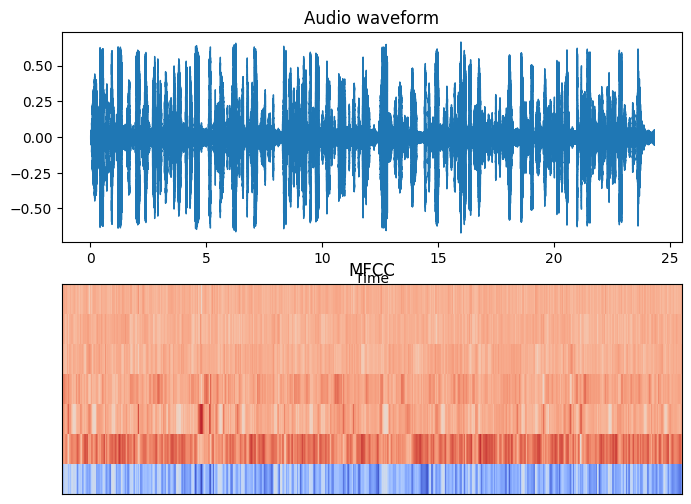

In [7]:
audio_file = f'{DATADIR}/train_small/wav/00834c0e904d40eda496e55010acebc5.wav'
mfcc, audio = mfcc_extract(audio_file, n_mfcc=7, apply_cmvn=False)

# We can plot the audio waveform and the features
fig, ax = plt.subplots(nrows=2, sharex=False, figsize=(8, 6))
librosa.display.waveshow(audio, sr=16000,  ax=ax[0])
ax[0].set(title='Audio waveform')

# notice the transposition before calling the display: librosa expects arrays of DxT, in which T is time, 
# however our feature extraction returns arrays of TxD
librosa.display.specshow(mfcc.T,  ax=ax[1])
# fig.colorbar(img, ax=[ax[1]])
ax[1].set(title='MFCC')


Inspect the output arrays and confirm they have the expected dimension (use `audio.shape` and `mfcc.shape`). **IMPORTANT:** You must understand what is the relation between the dimensions of audio and mfcc array!?

In [8]:

audio.shape, mfcc.shape

((388800,), (2427, 7))

Now, to run the data processing stage for the `train_small` partition we will simply instanciate the SLPdata class as described in the introduction Notebook. Take a sit because it can take a bit:

In [9]:
# We will use a dictionary to store the different feature extraction configurations
transform = {'mfcc7' : 
                 {  # audio_transform is exptected to be a function that takes as input a 
                    # filename and returns the features. For this reason, we use a lambda function
                    # to pass the parameters to the mfcc_extract function
                     'audio_transform': lambda x : mfcc_extract(x, 
                                                                mono=True, 
                                                                n_mfcc = 7, 
                                                                apply_vad=False, 
                                                                apply_cmvn=False)[0],
                     'chunk_transform': None, 
                     'chunk_size': -1, # <--- a negative value mean the whole file: we dont chunk the audio and
                                       #      we compute a feature matrix for each complete audio file
                     'chunk_hop': -1
                 }
            }


trainset = 'train_small'
transform_id = 'mfcc7'

train_small_slp = SLPdata(DATADIR, trainset, 
                 transform_id=transform_id, 
                 audio_transform=transform[transform_id]['audio_transform'], 
                 chunk_transform=transform[transform_id]['chunk_transform'],
                 chunk_size=transform[transform_id]['chunk_size'], 
                 chunk_hop=transform[transform_id]['chunk_hop']
                )


/home/luispma/slp_lab2/src/pf_tools.py:108: UserWarning: The feature directory already exists, and no new feature extraction will be performed.
  warnings.warn("The feature directory already exists, and no new feature extraction will be performed.")


Check your current folder, many things happened!! 

Notice that if you instanciate again the SLPdata class for the 'train_small' partition, the data will not be downloaded again. 
Additionally, if there is already a folder with the name `transform_id`, feature extraction will not run again. You need to delete from your filesystem the folder with the features if you want to run again the feature extraction (using the same identifier) or , alternatively, you can change the identifier. Be careful because you can easily increase the amount of data generated. If you try a feature extraction method that provides bad results, you probably don't want to keep the features in disk.

Now that we know the basics, it is time to try to improve your features. To do this, try to define some or all of the following steps to improve your feature extraction pipeline (students will be evaluated depending on their ability to solve the following functions):

#### Feature normalization:

In [51]:
def compute_cmvn(features, only_mean=False):
    # features shape is (Time, Dimension), so we calculate mean/std over axis 0
    mu = np.mean(features, axis=0)
    
    if only_mean:
        return features - mu
        
    stdev = np.std(features, axis=0)
    return (features - mu) / (stdev + 1e-8)

#### Delta computation:

In [52]:
def compute_delta(features, delta_order=2, keep_static=True):
    # features shape is (Time, Dimension)
    output_features = [features] if keep_static else []
    
    for order in range(1, delta_order + 1):
        # We specify axis=0 because our time dimension is the first one
        delta = librosa.feature.delta(features, order=order, axis=0)
        output_features.append(delta)
    
    # Concatenate horizontally (adding new columns/features for each timeframe)
    return np.hstack(output_features)

#### VAD removal:

In [10]:
def compute_vad(features, energy=None, y=None, percentile=30, min_speech_ratio=0.1,
                median_filter_size=5):
    
    from scipy.signal import medfilt

    # --- 1. Energy signal ---
    if energy is None:
        energy = features[:, 0]  # C0 is highly correlated with log-energy

    # --- 2. Percentile-based threshold (robust to loud/quiet recordings) ---
    threshold = np.percentile(energy, percentile)
    vad = energy > threshold

    # --- 3. Temporal smoothing via median filter ---
    # Removes isolated speech/silence blips (e.g. a single loud noise frame)
    if median_filter_size > 1:
        vad = medfilt(vad.astype(np.float32), kernel_size=median_filter_size) > 0.5

    vad = vad.astype(bool)

    # --- 4. Robustness guard ---
    # If VAD is too aggressive (e.g. near-silent recording), revert to all frames
    speech_ratio = np.mean(vad)
    if speech_ratio < min_speech_ratio:
        vad = np.ones(len(features), dtype=bool)

    return features[vad], vad

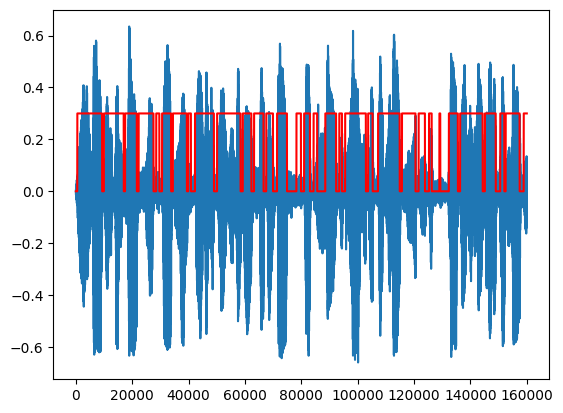

In [11]:
# The second returned expression of the VAD function is expected to be a boolean vector
# of one True or False, one per frame of the feature matrix. You can see the output of it and verify 
# if it's doing what is expected (removing low energy features) 

from functools import reduce

seconds = 10
mfcc_wo_vad, vad = compute_vad(mfcc,y=audio)
plt.plot(audio[:seconds*16000])
plt.plot(reduce(lambda a,b:a+b, ((0.3,)*160 if s else (0,)*160 for s in vad[:seconds*100])), 'r')


#### Test your functions

You can keep testing using an audio file with different configurations of the feature extraction Inspect the dimensions, verify that your code is doing what is expected, inspect and visualize the data using the previous examples and some of the lessons learnt in LAB1. You can also listen to some examples.

In [55]:
audio_file = f'{DATADIR}/train_small/wav/00834c0e904d40eda496e55010acebc5.wav'
mfcc_dd, _ = mfcc_extract(audio_file, apply_cmvn=False, delta_order=2)
mfcc_d, _ = mfcc_extract(audio_file, apply_cmvn=False, delta_order=1)
mfcc, _ = mfcc_extract(audio_file, apply_cmvn=False)


In [12]:
import IPython.display as ipd
ipd.Audio(audio_file)

#### Run new feature extraction configurations

Once you are done completing the additional modules, you can rerun the feature extraction process for the training set using new configurations. You can add new entries to the dictionary keeping several transformation configurations and instantiate the SLPdata class:

In [14]:
## <--- YOU CAN ADD NEW CONFIGURATIONS
transform['mfcc7'] = {  
                     'audio_transform': lambda x : mfcc_extract(x, mono=True, n_mfcc = 7, apply_vad=False, apply_cmvn=False)[0],
                     'chunk_transform': None, 
                     'chunk_size': -1, # <--- a negative value mean the whole file: we dont chunk the audio and
                                       #      we compute a feature matrix for each complete audio file
                     'chunk_hop': -1
                 }

transform['mfcc13'] = {  
                     'audio_transform': lambda x : mfcc_extract(x, mono=True, n_mfcc = 13, apply_vad=False, apply_cmvn=False)[0],
                     'chunk_transform': None, 
                     'chunk_size': -1, 
                     'chunk_hop': -1
                 }

transform['mfcc39_d_dd_vad_cmvn'] =  { 
                     'audio_transform': lambda x : mfcc_extract(x, mono=True, n_mfcc = 13, delta_order=2, apply_vad=True, apply_cmvn=True)[0],
                     'chunk_transform': None, 
                     'chunk_size': -1, 
                     'chunk_hop': -1
                 }

# NEW ULTIMATE CONFIGURATION:
transform['mfcc39_advanced'] =  { 
                     'audio_transform': lambda x : mfcc_extract(
                         x, mono=True, n_mfcc=13, delta_order=2, 
                         apply_vad=True, apply_cmvn=True, remove_c0=True,
                         remove_dc=True, apply_preemphasis=True
                     )[0],
                     'chunk_transform': None, 
                     'chunk_size': -1, 
                     'chunk_hop': -1
                 }
            

trainset = 'train_small'

# Select the configuration you want to use by uncommenting the right one:
# transform_id = 'mfcc7'
# transform_id = 'mfcc13'
# transform_id = 'mfcc39_d_dd_vad_cmvn' 
transform_id = 'mfcc39_advanced' # <--- using our new powerful pipeline!

train_small_slp = SLPdata(DATADIR, trainset, 
                 transform_id=transform_id, 
                 audio_transform=transform[transform_id]['audio_transform'], 
                 chunk_transform=transform[transform_id]['chunk_transform'],
                 chunk_size=transform[transform_id]['chunk_size'], 
                 chunk_hop=transform[transform_id]['chunk_hop']
                )

/home/luispma/slp_lab2/src/pf_tools.py:108: UserWarning: The feature directory already exists, and no new feature extraction will be performed.
  warnings.warn("The feature directory already exists, and no new feature extraction will be performed.")


### 1.3 GMMs for Gender modeling
The model in this baseline is extremely simple: we'll train an individual GMM model for each gender class on top of the features that we just extracted. Later, in prediction time, given a test audio sample, we'll compute the loglikelihood obtained with each GMM model and select as the predicted gender the one whose model gives the highest likelihood. Let's go for it!!

Notice that each training sample contains more than one frame (N dimension), so for GMM training we will first concatenate all data to have all training data in one array and the corresponding label (with same length):


In [15]:
from pf_tools import prepare_slp_data

# IN GMM training each training sample contains more than one frame;
# so we cocatenate all data to have all training data in one array 
# and the corresponding label (with same length)

# STEP 1: Instantiate the SLPdata object with the desired configuration
#         We will train using the following configuration
transform_id = 'mfcc39_advanced' # <--- CHANGE THIS
trainset = 'train_small'   # <--- CHANGE THIS IF YOU WANT TO USE THE COMPLETE TRAINING SET
train_small_slp = SLPdata(DATADIR, trainset, 
                 transform_id=transform_id, 
                 audio_transform=transform[transform_id]['audio_transform'], 
                 chunk_transform=transform[transform_id]['chunk_transform'],
                 chunk_size=transform[transform_id]['chunk_size'], 
                 chunk_hop=transform[transform_id]['chunk_hop']
                )

# STEP 2: Concatenate all data and labels in one data structure with 'data', 'label' 
#         and 'identifer' keys.
#         Each row corresponds to a frame of the feature matrix
train_data_and_labels = prepare_slp_data(train_small_slp)
train_data, train_labels = train_data_and_labels['data'], train_data_and_labels['label']

/home/luispma/slp_lab2/src/pf_tools.py:108: UserWarning: The feature directory already exists, and no new feature extraction will be performed.
  warnings.warn("The feature directory already exists, and no new feature extraction will be performed.")


Now we have three data structures containing the complete training dataset and the corresponding reference labels (we will not need the file indentifiers for trianing). Check the sizes. You can have a look to the content of one time instant. Notice that labels contain both gender and age. Do some checks on the data to be sure that everything is as expected:

In [16]:
# Check the traininig data. Notice that if you apply VAD, the size of the training data must be smaller than the complete data set. 
# Register the size in frames and in time of training data for each gender

train_data.shape, train_labels.shape

((768106, 38), (768106, 2))

Let's go training. Again, depending of the amount of data used, the model complexity and computational resources of the machine that you're using, this can take a while. So, relax while the computer works for you!

In [17]:
## STEP 3: TRAIN GMM models (ML) 
start = time.time()

models = {}
n_gauss = 16 ### <---- LAB WORK: You can play with the amount of Gaussians and register the impact on performance
max_iter = 50

for gender in GENDER_CLASSES:
    models[gender] = GaussianMixture(n_components=n_gauss, 
                                     covariance_type='diag', 
                                     max_iter=max_iter, 
                                     n_init=1, 
                                     init_params='kmeans', 
                                     verbose=2, 
                                     verbose_interval=1)
    
for gender in GENDER_CLASSES:
    print(f'Training model for {gender}')
    gender_label_pos = 0
    models[gender].fit(train_data[train_labels[:,gender_label_pos] == gender])
    
print(f'Finished training all GMM models in {time.time() - start}')


Training model for F
Initialization 0
  Iteration 1	 time lapse 2.14734s	 ll change inf
  Iteration 2	 time lapse 0.32881s	 ll change 0.08174
  Iteration 3	 time lapse 0.36761s	 ll change 0.03680
  Iteration 4	 time lapse 0.30906s	 ll change 0.02602
  Iteration 5	 time lapse 0.31581s	 ll change 0.01915
  Iteration 6	 time lapse 0.30963s	 ll change 0.01360
  Iteration 7	 time lapse 0.32304s	 ll change 0.00955
  Iteration 8	 time lapse 0.32058s	 ll change 0.00680
  Iteration 9	 time lapse 0.32782s	 ll change 0.00499
  Iteration 10	 time lapse 0.30629s	 ll change 0.00378
  Iteration 11	 time lapse 0.30914s	 ll change 0.00297
  Iteration 12	 time lapse 0.31317s	 ll change 0.00242
  Iteration 13	 time lapse 0.30208s	 ll change 0.00201
  Iteration 14	 time lapse 0.30169s	 ll change 0.00174
  Iteration 15	 time lapse 0.30561s	 ll change 0.00152
  Iteration 16	 time lapse 0.30878s	 ll change 0.00137
  Iteration 17	 time lapse 0.32140s	 ll change 0.00126
  Iteration 18	 time lapse 0.27886s	 ll 

Once the models have been trained, we can store them in disk for later usage. Again, be careful and avoid storing versions of useless models. By default, the model is stored in a folder inside the data partition folder and contains the feature extraction in the name and the date.

In [18]:
# STEP 4: Save the models
from pf_tools import save_model
model_id = save_model(models, f'gmm_{transform_id}', f'{DATADIR}/{trainset}/models/gender/')
print(f'Model {model_id} saved in {DATADIR}/{trainset}/models/gender/')

Model saved to /home/luispma/slp_lab2/data/train_small/models/gender//gmm_mfcc39_advanced_2026-05-17_12:42:50/model.pkl
Model gmm_mfcc39_advanced_2026-05-17_12:42:50 saved in /home/luispma/slp_lab2/data/train_small/models/gender/


You can also check the `sklearn` documentation and inspect the models trained:

In [19]:
models['M'].means_.shape

(16, 38)

If you later need to reload your models (because you want to use them to predict on new data), you will have to do the following:

In [20]:
from pf_tools import load_model

# model_id = 'gmm_mfcc39_advanced_2026-05-15_15:59:55' # <--- CHANGE THIS ACCORDING TO THE MODEL YOU WANT TO LOAD

filename = f'{DATADIR}/{trainset}/models/gender/{model_id}/model.pkl'
models = load_model(filename)


### 1.4 Classification of the dev set

Now that we  already have trained models, let's predict/identify the speakers gender in new audio data and test our model!!! 

But first, we need to obtain the development partition and apply the same feature extraction as previously (using the SLPdata class).

**IMPORTANT WARNING** Make sure to use the exact same feature extraction configuration as the one used for the train set. Otherwise, your model will be in disagreement with your evaluation data, and very likely, will not work at all.


In [21]:
transform_id = 'mfcc39_advanced' ## <--- CHANGE THIS?
    
dev_slp = SLPdata(DATADIR,'dev', 
                 transform_id=transform_id, 
                 audio_transform=transform[transform_id]['audio_transform'], 
                 chunk_transform=transform[transform_id]['chunk_transform'],
                 chunk_size=transform[transform_id]['chunk_size'], 
                 chunk_hop=transform[transform_id]['chunk_hop']
                )

/home/luispma/slp_lab2/src/pf_tools.py:108: UserWarning: The feature directory already exists, and no new feature extraction will be performed.
  warnings.warn("The feature directory already exists, and no new feature extraction will be performed.")


Now, we will use the SLPdata instance to load the data and use the models for scoring. 

First, we will store the data in a dictionary, with keys corresponding to each file of the development and with value a dictionary containing the 'data' and 'label'. We will use the previous `prepare_slp_data` function with different options:

In [22]:
dev_data = prepare_slp_data(dev_slp, collapse_samples=False, expand_labels=False)

Now, we will compute the log-likelihood for every file and gender model, obtain the prediction and store everything (including the filenames and the reference label) in a dictionary. We provide a gmm_predict function to do this:

In [26]:
from pf_tools import gmm_predict

start = time.time()
gender_label_pos = 0
results_dev = gmm_predict(models, dev_data, GENDER_CLASSES, label_pos=gender_label_pos)
print(f'Finished predicting all data in {time.time() - start}')


100%|██████████| 117/117 [00:00<00:00, 383.58it/s]

Finished predicting all data in 0.30904674530029297


You can have a look to the contents of this results structure:

In [27]:
results_dev['hyp'][:10], results_dev['ref'][:10], results_dev['fileids'][:10], results_dev['llhs'][:10,:]


(['F', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'M'],
 ['F', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'F', 'M'],
 ['0159b474eeac423d9f9931e5ae55f900',
  '0213f62f0ef9408eb5644574591811cc',
  '02674eaf2635448cab4c3d547ebc9b6f',
  '03cbf9c4e37044ce80e83c1ba0f5d99c',
  '05fe9e29ac624ba486d073fd1f3b1e64',
  '070ccc92545e4bbb8346dcb64d7c5315',
  '09b7921c071f4296a9f869df7c127e28',
  '0a9160135bbb421eae638c9be6687e51',
  '0c850fc8a6b8458997122af021364891',
  '117b63d42d5b484e8d49dc766889f406'],
 array([[-49.7795639 , -52.00030518],
        [-50.5554924 , -52.27453613],
        [-50.58651733, -52.39538574],
        [-49.98952866, -51.97356033],
        [-49.92127228, -52.15808868],
        [-50.13814926, -52.34410477],
        [-50.05625916, -52.1672287 ],
        [-50.97511673, -53.01926041],
        [-50.05032349, -52.33732605],
        [-51.50162888, -50.26651001]]))

We will save the results object of the development set. We will use it later to generate the final submission file:

In [28]:
# save results structure 
# model_id = 'gmm_mfcc7_2026-05-06_15:54:37' # <--- CHANGE THIS ACCORDING TO THE MODEL YOU WANT TO LOAD
filename = f'{DATADIR}/{trainset}/models/gender/{model_id}/dev.pkl'
pickle.dump(results_dev, open(filename, 'wb'))


### 1.5 System Evaluation
After running the previous cells, we obtained two arrays with the reference and hypothesis labels (we can also reload them in case we need them). We can use these to compute different evaluation metrics and inspect the performance (and potential problems) of our system. Of course, you will only be able to do this assessment with the development set, since you don't have access to the eval labels.

You can for instance obtain a classification report summary:

In [29]:
ref, hyp = results_dev['ref'], results_dev['hyp']
print(classification_report(ref, hyp, target_names=GENDER_CLASSES))

              precision    recall  f1-score   support

           F       1.00      1.00      1.00        60
           M       1.00      1.00      1.00        57

    accuracy                           1.00       117
   macro avg       1.00      1.00      1.00       117
weighted avg       1.00      1.00      1.00       117



Overall accuracy (this will be the **main metric for system ranking**):

In [30]:
accuracy_score(ref, hyp)

1.0

Or a confusion matrix: 

In [31]:
cm = confusion_matrix(ref, hyp)
cm

array([[60,  0],
       [ 0, 57]])

and visualize it:

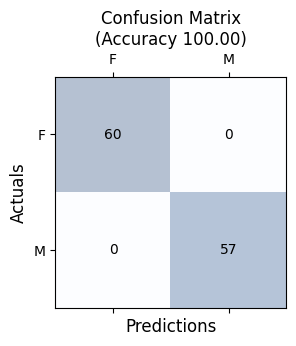

In [32]:
from pf_tools import plot_confusion_matrix
plot_confusion_matrix(cm, GENDER_CLASSES, title=f'Confusion Matrix\n(Accuracy {100*accuracy_score(ref, hyp):.2f})')

As a form of approximate reference, these are the accuracies that can be obtained with the following configurations using the `train_small` data set:

|       |     Accuracy       |
|-------|--------------------|
| mfcc7 (16 gauss)| 94.02    |

These results are very good. Even with a very simple baseline, it is possible to achieve excellent results in gender classification. This is a pretty simple task. Age regression will be different.

### 1.6 Classification of the evl partition

Once you are happy with your system and the results obtained in the development set, you are ready to generate the predictions on the `'evl'` partition. To do that, you have to follow the same process as for the development partition, but of course, this time you will not be able to obtain performance results because you don't have labels for this partition. 

We start by instantiating the `SLPdata` class for the `'evl'` partition:


In [33]:
# model_id = 'gmm_mfcc39_advanced_2026-05-15_15:59:55' # <--- CHANGE THIS ACCORDING TO THE MODEL YOU WANT TO LOAD
# filename = f'{DATADIR}/{trainset}/models/gender/{model_id}/model.pkl'
# models = pickle.load(open(filename, 'rb'))


evl_slp = SLPdata(DATADIR,'evl', 
                 transform_id=transform_id, 
                 audio_transform=transform[transform_id]['audio_transform'], 
                 chunk_transform=transform[transform_id]['chunk_transform'],
                 chunk_size=transform[transform_id]['chunk_size'], 
                 chunk_hop=transform[transform_id]['chunk_hop']
                )


/home/luispma/slp_lab2/src/pf_tools.py:108: UserWarning: The feature directory already exists, and no new feature extraction will be performed.
  warnings.warn("The feature directory already exists, and no new feature extraction will be performed.")


Then, we load the evaluation data and apply the model(s) to the new `'evl'` data. We will also save the results for later use. 

In [34]:
evl_data = prepare_slp_data(evl_slp, collapse_samples=False, expand_labels=False)
gender_label_pos = 0

start = time.time()
results_evl = gmm_predict(models, evl_data, GENDER_CLASSES, label_pos=gender_label_pos)
filename = f'{DATADIR}/{trainset}/models/gender/{model_id}/evl.pkl'
pickle.dump(results_evl, open(filename, 'wb'))

print(f'Finished predicting all data in {time.time() - start}')

100%|██████████| 145/145 [00:00<00:00, 572.76it/s]

Finished predicting all data in 0.2572803497314453


## 2. The openSMILE and SVM baseline system 
This second conventional baseline consists of a segment (file) based feature extraction module. That is, for each data file, a single feature vector will be extracted. In particular, we will use the popular `openSMILE` toolkit.

The feature extraction step is followed by a simple linear SVM (using the `sklearn` module). 

Student groups will be graded depending on their ability to explore different feature configurations and model alternatives/configurations.

This set-up will be the basis for our age estimator, that  will represent each audio file as single vector followed by a SV regressor.

### 2.1 The openSMILE feature extraction module
[openSMILE](https://audeering.github.io/opensmile-python/) is a popular feature extraction toolkit, specially devoted to speech paralinguistic tasks. It is based in a two stage approach: 

1) It extracts low-level descriptors at the frame level (just like previous MFCCs)
2) It applies a set of functionals that summarize a time-varying feature sequence into a fixed-size one dimensional feature vector.

For this baseline system, we will use functional level features. Have a look to  and run the following code snipet:


In [35]:
# https://audeering.github.io/opensmile-python/

smile = opensmile.Smile(
    feature_set=opensmile.FeatureSet.ComParE_2016,
    feature_level=opensmile.FeatureLevel.Functionals
)
audio_file = f'{DATADIR}/train_small/wav/00834c0e904d40eda496e55010acebc5.wav'
df = smile.process_file(audio_file) # <-- This is a pandas dataframe

You can explore the contents of the dataframe, convert to a numpy array and check the dimensions. Then, write the function of two arguments that receive an audio filename and an smile object and returns the numpy feature array.

In [36]:
print(df.columns.to_list()) 

['audspec_lengthL1norm_sma_range', 'audspec_lengthL1norm_sma_maxPos', 'audspec_lengthL1norm_sma_minPos', 'audspec_lengthL1norm_sma_quartile1', 'audspec_lengthL1norm_sma_quartile2', 'audspec_lengthL1norm_sma_quartile3', 'audspec_lengthL1norm_sma_iqr1-2', 'audspec_lengthL1norm_sma_iqr2-3', 'audspec_lengthL1norm_sma_iqr1-3', 'audspec_lengthL1norm_sma_percentile1.0', 'audspec_lengthL1norm_sma_percentile99.0', 'audspec_lengthL1norm_sma_pctlrange0-1', 'audspec_lengthL1norm_sma_stddev', 'audspec_lengthL1norm_sma_skewness', 'audspec_lengthL1norm_sma_kurtosis', 'audspec_lengthL1norm_sma_meanSegLen', 'audspec_lengthL1norm_sma_maxSegLen', 'audspec_lengthL1norm_sma_minSegLen', 'audspec_lengthL1norm_sma_segLenStddev', 'audspec_lengthL1norm_sma_upleveltime25', 'audspec_lengthL1norm_sma_upleveltime50', 'audspec_lengthL1norm_sma_upleveltime75', 'audspec_lengthL1norm_sma_upleveltime90', 'audspec_lengthL1norm_sma_risetime', 'audspec_lengthL1norm_sma_leftctime', 'audspec_lengthL1norm_sma_lpgain', 'audspe

In [37]:
# This must return a numpy array of shape (1,X). X depends on the opensmile configuration 
def extract_smile(filename, smile):
    return smile.process_file(filename).to_numpy()

Exactly like in the GMM baseline system, we will create a configuration transformation and instantiate the SLPdata class to do the feature extraction for each data partition. We will store all the SLPdata objects in a dictionary.

In [38]:
# transform = {}

transform['compare2016'] = {
    'audio_transform': 
        lambda x : extract_smile(x, 
            smile = opensmile.Smile(
                                feature_set=opensmile.FeatureSet.ComParE_2016, 
                                feature_level=opensmile.FeatureLevel.Functionals,
                            )
            ), 
    'chunk_transform': None,
    'chunk_size': 0,
    'chunk_hop':0   
}

transform['gemaps'] = {
    'audio_transform': 
        lambda x : extract_smile(x, 
            smile = opensmile.Smile(
                                feature_set=opensmile.FeatureSet.GeMAPSv01b, 
                                feature_level=opensmile.FeatureLevel.Functionals,
                            )
            ), 
    'chunk_transform': None,
    'chunk_size': 0,
    'chunk_hop':0   
}

# --- NEW ADDITION: Extended GeMAPS ---
transform['egemaps'] = {
    'audio_transform': 
        lambda x : extract_smile(x, 
            smile = opensmile.Smile(
                                feature_set=opensmile.FeatureSet.eGeMAPSv02, # <--- eGeMAPS v02 
                                feature_level=opensmile.FeatureLevel.Functionals,
                            )
            ), 
    'chunk_transform': None,
    'chunk_size': 0,
    'chunk_hop':0   
}

In [39]:

transform_id = 'egemaps' # <--- Change this to the configuration you want to use

slp_partitions = {}
# for partition in ('train', 'train_small', 'dev', 'evl'):
for partition in ('train', 'dev', 'evl'):
    slp_partitions[partition] = SLPdata(DATADIR, partition, 
                    transform_id=transform_id, 
                    audio_transform=transform[transform_id]['audio_transform'], 
                    chunk_transform=transform[transform_id]['chunk_transform'],
                    chunk_size=transform[transform_id]['chunk_size'], 
                    chunk_hop=transform[transform_id]['chunk_hop']
                    )


0it [00:00, ?it/s]

3238it [19:34,  2.76it/s]
/home/luispma/slp_lab2/src/pf_tools.py:108: UserWarning: The feature directory already exists, and no new feature extraction will be performed.
  warnings.warn("The feature directory already exists, and no new feature extraction will be performed.")
/home/luispma/slp_lab2/src/pf_tools.py:108: UserWarning: The feature directory already exists, and no new feature extraction will be performed.
  warnings.warn("The feature directory already exists, and no new feature extraction will be performed.")


And we will load the data and labels of all paritions to be get prepared for training and evaluation.

In [41]:
from pf_tools import prepare_slp_data

#   Concatenate all data and labels
#   Each row corresponds to a file
#   We store the data, labels and file identifiers of each partition in dictionaries 
#     with the partition name as key


gender_label_pos = 0
age_label_pos = 1

data, labels_gender, labels_age, fileids = {}, {}, {}, {}
# for partition in ('train', 'train_small', 'dev', 'evl'):
for partition in ('train', 'dev', 'evl'):
    data_and_labels = prepare_slp_data(slp_partitions[partition])
    print(f'Partition: {partition}')
    print(f'Number of samples: {data_and_labels["data"].shape[0]}')
    print(f'Number of features: {data_and_labels["data"].shape[1]}')
    print(f'Number of labels: {len(np.unique(data_and_labels["label"][:,gender_label_pos]))}')
    print(f'Number of identifiers (samples): {len(np.unique(data_and_labels["identifiers"]))}')
    print('---')
    data[partition] = data_and_labels['data']
    labels_gender[partition] = data_and_labels['label'][:,gender_label_pos]
    labels_age[partition] = data_and_labels['label'][:,age_label_pos]
    if partition != 'evl':
        labels_age[partition] = np.float32(labels_age[partition])
    fileids[partition] = data_and_labels['identifiers']
    
    

Partition: train
Number of samples: 3238
Number of features: 88
Number of labels: 2
Number of identifiers (samples): 3238
---
Partition: dev
Number of samples: 117
Number of features: 88
Number of labels: 2
Number of identifiers (samples): 117
---
Partition: evl
Number of samples: 145
Number of features: 88
Number of labels: 1
Number of identifiers (samples): 145
---


### 2.2 SVM training and evaluation
This baseline system is based on segment/file level features. This means that we have a single feature vector per file. Models like Support Vector Machines excel in taks with small training samples (and high feature dimensionality). We will use scikit learn for model training. We will use a linear SVM, but students are encouraged to try other similar models and configurations.

Have a look to the the following code snipet, it will train the model, run prediction on both dev and evl partitions and save the results:

In [81]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from pf_tools import save_model
import pickle

trainset = 'train_small'

# --- MODEL CONFIGURATIONS ---
# We define a dictionary with both our baseline (Linear) and our GridSearch optimized (RBF) models.

models_to_test = {
    'svm_linear_scaled': make_pipeline(StandardScaler(), SVC(kernel='linear')),
    'svm_rbf_optimized': make_pipeline(StandardScaler(), SVC(kernel='rbf', C=10, gamma=0.001))
}

# --- LOOP, TRAIN, AND PREDICT ---
for model_name, model in models_to_test.items():
    print(f"\n=== Processing: {model_name} ===")
    
    # 1. Train the model
    print(f"Training on {trainset}...")
    model.fit(data[trainset], labels_gender[trainset])  

    # 2. Save the model
    # We combine your custom model_name with the transform_id (e.g., 'egemaps')
    full_id = f'{model_name}_{transform_id}'
    model_id = save_model(model, full_id, f'{DATADIR}/{trainset}/models/gender/')
    print(f'Model saved with ID: {model_id}')

    # 3. Predict on Dev set and save
    dev_results = model.predict(data['dev']) 
    filename_dev = f'{DATADIR}/{trainset}/models/gender/{model_id}/dev.pkl'
    pickle.dump({'hyp': dev_results, 'fileids': fileids['dev']}, open(filename_dev, 'wb'))
    
    # 4. Predict on Eval set and save
    evl_results = model.predict(data['evl']) 
    filename_evl = f'{DATADIR}/{trainset}/models/gender/{model_id}/evl.pkl'
    pickle.dump({'hyp': evl_results, 'fileids': fileids['evl']}, open(filename_evl, 'wb'))
    
    print(f"Predictions saved successfully!")

print("\nAll configurations tested and saved!")


=== Processing: svm_linear_scaled ===
Training on train_small...
Model saved to /home/luispma/slp_lab2/data/train_small/models/gender//svm_linear_scaled_compare2016_2026-05-17_12:15:03/model.pkl
Model saved with ID: svm_linear_scaled_compare2016_2026-05-17_12:15:03
Predictions saved successfully!

=== Processing: svm_rbf_optimized ===
Training on train_small...
Model saved to /home/luispma/slp_lab2/data/train_small/models/gender//svm_rbf_optimized_compare2016_2026-05-17_12:15:05/model.pkl
Model saved with ID: svm_rbf_optimized_compare2016_2026-05-17_12:15:05
Predictions saved successfully!

All configurations tested and saved!


Let's see the results we obtain in the dev partition:


RESULTS FOR: svm_linear_scaled
              precision    recall  f1-score   support

           F       1.00      1.00      1.00        60
           M       1.00      1.00      1.00        57

    accuracy                           1.00       117
   macro avg       1.00      1.00      1.00       117
weighted avg       1.00      1.00      1.00       117



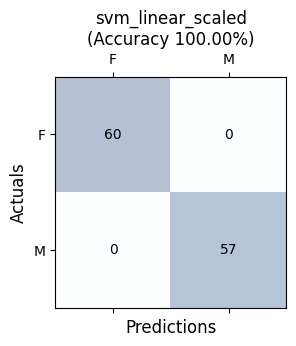


RESULTS FOR: svm_rbf_optimized
              precision    recall  f1-score   support

           F       1.00      0.63      0.78        60
           M       0.72      1.00      0.84        57

    accuracy                           0.81       117
   macro avg       0.86      0.82      0.81       117
weighted avg       0.86      0.81      0.81       117



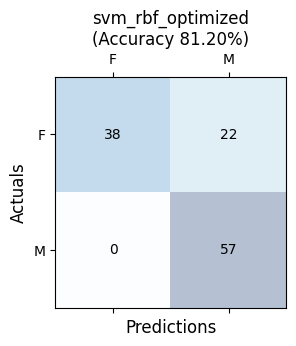

In [82]:
from pf_tools import plot_confusion_matrix
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Simply loop through the models we already have in memory
for model_name, model in models_to_test.items():
    print(f"\n" + "="*30)
    print(f"RESULTS FOR: {model_name}")
    print("="*30)
    
    # Generate predictions directly
    hyp = model.predict(data['dev'])
    ref = labels_gender['dev']
    
    # Print report and plot
    print(classification_report(ref, hyp))
    
    cm = confusion_matrix(ref, hyp)
    plot_confusion_matrix(cm, GENDER_CLASSES, title=f'{model_name}\n(Accuracy {100*accuracy_score(ref, hyp):.2f}%)')

As a form of approximate reference, the linear SVM with gemapsv01 achieves an accuracy of ~99.15% using the `train_small` data set.

## 3 Develop the Age estimator baseline

Based on the openSMILE + SVM example, it is now very easy to adapt to an age regression task.

Notice that we have previously created the structures labels_gender and labels_age, containing the ground-truth for gender and age respetively. We can now use the later and change the SVM with a SVR model:

In [83]:
from sklearn.svm import SVR
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from pf_tools import save_model
import pickle
import numpy as np

trainset = 'train_small'

# --- THE MASTER MODEL DICTIONARY ---
all_models = {
    # The Baseline SVRs
    'svr_linear_scaled': make_pipeline(StandardScaler(), SVR(kernel='linear', C=1)),
    'svr_rbf_default': make_pipeline(StandardScaler(), SVR(kernel='rbf', C=1.0, epsilon=0.1)),
    'svr_rbf_high_C': make_pipeline(StandardScaler(), SVR(kernel='rbf', C=10.0, epsilon=0.5, gamma='scale')),
    
    # The Advanced Setups
    'svr_pca_optimized': make_pipeline(
        StandardScaler(), 
        PCA(n_components=100, random_state=42), 
        SVR(kernel='rbf', C=10.0, epsilon=0.5, gamma='scale')
    ),
    'hist_gradient_boosting': HistGradientBoostingRegressor(
        max_iter=500, 
        learning_rate=0.05, 
        max_depth=5, 
        random_state=42
    )
}

# --- TRAIN AND SAVE EVERYTHING ---
print(f"=== STARTING TRAINING PIPELINE (Features: {transform_id}) ===\n")

for model_name, model in all_models.items():
    print(f"Training {model_name}...")
    
    # Train the model
    model.fit(data[trainset], np.float32(labels_age[trainset]).ravel())  

    # Save the model
    full_id = f'{model_name}_{transform_id}'
    model_id = save_model(model, full_id, f'{DATADIR}/{trainset}/models/age/')

    # Predict and save Dev set
    dev_results = model.predict(data['dev']) 
    filename_dev = f'{DATADIR}/{trainset}/models/age/{model_id}/dev.pkl'
    pickle.dump({'hyp': dev_results, 'fileids': fileids['dev']}, open(filename_dev, 'wb'))
    
    # Predict and save Eval set
    evl_results = model.predict(data['evl']) 
    filename_evl = f'{DATADIR}/{trainset}/models/age/{model_id}/evl.pkl'
    pickle.dump({'hyp': evl_results, 'fileids': fileids['evl']}, open(filename_evl, 'wb'))
    
    print(f"  -> Model {model_id} saved!")
    
print("\nAll models trained and saved successfully!")

=== STARTING TRAINING PIPELINE (Features: compare2016) ===

Training svr_linear_scaled...
Model saved to /home/luispma/slp_lab2/data/train_small/models/age//svr_linear_scaled_compare2016_2026-05-17_12:15:09/model.pkl
  -> Model svr_linear_scaled_compare2016_2026-05-17_12:15:09 saved!
Training svr_rbf_default...
Model saved to /home/luispma/slp_lab2/data/train_small/models/age//svr_rbf_default_compare2016_2026-05-17_12:15:11/model.pkl
  -> Model svr_rbf_default_compare2016_2026-05-17_12:15:11 saved!
Training svr_rbf_high_C...
Model saved to /home/luispma/slp_lab2/data/train_small/models/age//svr_rbf_high_C_compare2016_2026-05-17_12:15:13/model.pkl
  -> Model svr_rbf_high_C_compare2016_2026-05-17_12:15:13 saved!
Training svr_pca_optimized...
Model saved to /home/luispma/slp_lab2/data/train_small/models/age//svr_pca_optimized_compare2016_2026-05-17_12:15:17/model.pkl
  -> Model svr_pca_optimized_compare2016_2026-05-17_12:15:17 saved!
Training hist_gradient_boosting...
Model saved to /home

Let's see the results we obtain now in the age estimation class in the dev partition. Notice that instead of Accuracy, for the regression we will use Mean Absolute Error and Mean Square Error:

In [84]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Ground truth references for the dev set
ref = np.float32(labels_age['dev']).ravel()

print(f"=== AGE ESTIMATION LEADERBOARD ({transform_id.upper()}) ===")

for model_name, model in all_models.items():
    # Make predictions on the Dev set
    hyp = model.predict(data['dev'])
    
    # Print the error metrics
    print(f"\n{model_name.upper()}:")
    print(f"  MAE: {mean_absolute_error(ref, hyp):.2f} years")
    print(f"  MSE: {mean_squared_error(ref, hyp):.2f}")

=== AGE ESTIMATION LEADERBOARD (COMPARE2016) ===

SVR_LINEAR_SCALED:
  MAE: 11.32 years
  MSE: 203.75

SVR_RBF_DEFAULT:
  MAE: 8.46 years
  MSE: 126.38

SVR_RBF_HIGH_C:
  MAE: 8.60 years
  MSE: 120.80

SVR_PCA_OPTIMIZED:
  MAE: 9.08 years
  MSE: 129.65

HIST_GRADIENT_BOOSTING:
  MAE: 8.44 years
  MSE: 124.75


#TEST EVERYTHING BETTER

In [44]:
from sklearn.svm import SVR
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import RandomizedSearchCV
from pf_tools import save_model
import pickle
import numpy as np

trainset = 'train'
y_train = np.float32(labels_age[trainset]).ravel()

# Adaptive PCA components — caps at number of available features
n_pca = min(100, data[trainset].shape[1])
print(f"Feature dimensionality: {data[trainset].shape[1]} → PCA n_components set to {n_pca}")

# ================================================================
# PART A: STANDARD MODELS (with hyperparameter tuning on the best one)
# ================================================================

# --- 1. Quick baseline models (no tuning) ---
all_models = {
    'svr_linear_scaled': make_pipeline(StandardScaler(), SVR(kernel='linear', C=1)),
    'svr_rbf_default':   make_pipeline(StandardScaler(), SVR(kernel='rbf', C=1.0, epsilon=0.1)),
    'svr_rbf_high_C':    make_pipeline(StandardScaler(), SVR(kernel='rbf', C=10.0, epsilon=0.5, gamma='scale')),
    'svr_pca_optimized': make_pipeline(
                            StandardScaler(),
                            PCA(n_components=n_pca, random_state=42),
                            SVR(kernel='rbf', C=10.0, epsilon=0.5, gamma='scale')
                         ),
    'hist_gradient_boosting': HistGradientBoostingRegressor(
                                max_iter=500, learning_rate=0.05,
                                max_depth=5, random_state=42
                              ),
}

# --- 2. Hyperparameter tuning for the RBF SVR ---
print("=== Tuning SVR hyperparameters (RandomizedSearchCV) ===")
base_svr_pipeline = make_pipeline(StandardScaler(), SVR(kernel='rbf'))
param_dist = {
    'svr__C':       [0.1, 1, 10, 50, 100],
    'svr__epsilon': [0.1, 0.5, 1.0, 2.0],
    'svr__gamma':   ['scale', 'auto'],
}
search = RandomizedSearchCV(
    base_svr_pipeline, param_dist,
    n_iter=20, cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1, random_state=42, verbose=1
)
search.fit(data[trainset], y_train)
print(f"  Best params : {search.best_params_}")
print(f"  Best CV MAE : {-search.best_score_:.2f} years")

# Add the tuned model to the dict so it goes through the same save/predict loop
all_models['svr_rbf_tuned'] = search.best_estimator_

# ================================================================
# PART B: GENDER-CONDITIONED SVR (pickle-safe — no lambda)
# ================================================================
print("\n=== Training Gender-Conditioned SVR ===")

class GenderConditionedSVR:
    """Trains one SVR per gender; routes predictions through the gender label."""

    def __init__(self, C, epsilon, gamma):
        # Store params directly instead of a lambda — pickle-safe
        self.C = C
        self.epsilon = epsilon
        self.gamma = gamma
        self.models_ = {}

    def _make_pipeline(self):
        return make_pipeline(
            StandardScaler(),
            SVR(kernel='rbf', C=self.C, epsilon=self.epsilon, gamma=self.gamma)
        )

    def fit(self, X, y_age, y_gender):
        for gender in ['M', 'F']:
            mask = y_gender == gender
            print(f"  [{gender}] training on {mask.sum()} samples...")
            self.models_[gender] = self._make_pipeline()
            self.models_[gender].fit(X[mask], y_age[mask])
        return self

    def predict(self, X, y_gender):
        hyp = np.zeros(len(X))
        for gender in ['M', 'F']:
            mask = y_gender == gender
            if mask.sum() > 0:
                hyp[mask] = self.models_[gender].predict(X[mask])
        return np.clip(hyp, 0, 100)


# Use the best tuned params found above
gender_svr = GenderConditionedSVR(
    C       = search.best_params_['svr__C'],
    epsilon = search.best_params_['svr__epsilon'],
    gamma   = search.best_params_['svr__gamma']
)
gender_svr.fit(data[trainset], y_train, labels_gender[trainset])

# ================================================================
# PART C: TRAIN, SAVE, AND PREDICT — STANDARD MODELS
# ================================================================
print(f"\n=== STARTING TRAINING PIPELINE (Features: {transform_id}) ===\n")

for model_name, model in all_models.items():
    print(f"Training {model_name}...")
    if model_name != 'svr_rbf_tuned':         # already fitted during search
        model.fit(data[trainset], y_train)

    full_id  = f'{model_name}_{transform_id}'
    model_id = save_model(model, full_id, f'{DATADIR}/{trainset}/models/age/')

    dev_results = np.clip(model.predict(data['dev']), 0, 100)
    pickle.dump({'hyp': dev_results, 'fileids': fileids['dev']},
                open(f'{DATADIR}/{trainset}/models/age/{model_id}/dev.pkl', 'wb'))

    evl_results = np.clip(model.predict(data['evl']), 0, 100)
    pickle.dump({'hyp': evl_results, 'fileids': fileids['evl']},
                open(f'{DATADIR}/{trainset}/models/age/{model_id}/evl.pkl', 'wb'))

    print(f"  -> Model {model_id} saved!")

# ================================================================
# PART D: SAVE GENDER-CONDITIONED MODEL
# ================================================================
gc_full_id  = f'gender_conditioned_svr_{transform_id}'
gc_model_id = save_model(gender_svr, gc_full_id, f'{DATADIR}/{trainset}/models/age/')

gc_dev = gender_svr.predict(data['dev'], labels_gender['dev'])
pickle.dump({'hyp': gc_dev, 'fileids': fileids['dev']},
            open(f'{DATADIR}/{trainset}/models/age/{gc_model_id}/dev.pkl', 'wb'))

gc_evl = gender_svr.predict(data['evl'], labels_gender['evl'])
pickle.dump({'hyp': gc_evl, 'fileids': fileids['evl']},
            open(f'{DATADIR}/{trainset}/models/age/{gc_model_id}/evl.pkl', 'wb'))

print(f"\n  -> Gender-conditioned model {gc_model_id} saved!")
print("\nAll models trained and saved successfully!")

Feature dimensionality: 88 → PCA n_components set to 88
=== Tuning SVR hyperparameters (RandomizedSearchCV) ===
Fitting 5 folds for each of 20 candidates, totalling 100 fits


  Best params : {'svr__gamma': 'auto', 'svr__epsilon': 0.5, 'svr__C': 10}
  Best CV MAE : 7.95 years

=== Training Gender-Conditioned SVR ===
  [M] training on 1607 samples...
  [F] training on 1631 samples...

=== STARTING TRAINING PIPELINE (Features: egemaps) ===

Training svr_linear_scaled...
Model saved to /home/luispma/slp_lab2/data/train/models/age//svr_linear_scaled_egemaps_2026-05-17_13:15:11/model.pkl
  -> Model svr_linear_scaled_egemaps_2026-05-17_13:15:11 saved!
Training svr_rbf_default...
Model saved to /home/luispma/slp_lab2/data/train/models/age//svr_rbf_default_egemaps_2026-05-17_13:15:11/model.pkl
  -> Model svr_rbf_default_egemaps_2026-05-17_13:15:11 saved!
Training svr_rbf_high_C...
Model saved to /home/luispma/slp_lab2/data/train/models/age//svr_rbf_high_C_egemaps_2026-05-17_13:15:12/model.pkl
  -> Model svr_rbf_high_C_egemaps_2026-05-17_13:15:12 saved!
Training svr_pca_optimized...
Model saved to /home/luispma/slp_lab2/data/train/models/age//svr_pca_optimized_egemap

In [45]:
# ================================================================
# EVALUATION CELL
# ================================================================
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

ref = np.float32(labels_age['dev']).ravel()

print(f"=== AGE ESTIMATION LEADERBOARD ({transform_id.upper()}) ===\n")
print(f"{'Model':<35} {'MAE':>8} {'RMSE':>8}")
print("-" * 55)

results_summary = {}

# --- Standard models ---
for model_name, model in all_models.items():
    hyp = np.clip(model.predict(data['dev']), 0, 100)
    mae  = mean_absolute_error(ref, hyp)
    rmse = np.sqrt(mean_squared_error(ref, hyp))
    results_summary[model_name] = mae
    print(f"{model_name:<35} {mae:>7.2f}y {rmse:>7.2f}")

# --- Gender-conditioned model ---
hyp_gc = gender_svr.predict(data['dev'], labels_gender['dev'])
mae_gc  = mean_absolute_error(ref, hyp_gc)
rmse_gc = np.sqrt(mean_squared_error(ref, hyp_gc))
results_summary['gender_conditioned_svr'] = mae_gc
print(f"{'gender_conditioned_svr':<35} {mae_gc:>7.2f}y {rmse_gc:>7.2f}")

# --- Winner ---
print("-" * 55)
best_model = min(results_summary, key=results_summary.get)
print(f"\n🏆 Best model: {best_model}  (MAE = {results_summary[best_model]:.2f} years)")

=== AGE ESTIMATION LEADERBOARD (EGEMAPS) ===

Model                                    MAE     RMSE
-------------------------------------------------------
svr_linear_scaled                      9.45y   11.39
svr_rbf_default                        8.82y   11.12
svr_rbf_high_C                         9.47y   11.50
svr_pca_optimized                      9.47y   11.50
hist_gradient_boosting                 9.36y   11.58
svr_rbf_tuned                          9.47y   11.50
gender_conditioned_svr                 9.47y   11.52
-------------------------------------------------------

🏆 Best model: svr_rbf_default  (MAE = 8.82 years)


The MAE result obtained with this simple system is about 9.4.

This is not very strong. Of course, the task is more difficult!!
Now you can try to play with the feature extraction and SVR configurations to improve the performance of the openSMILE + SVR age estimator. 

In the next sessions, we will explore richer speech reprentations that will contribute to obtain a better system.

## 4 Submitting your systems predictions to the challenge

The challenge will focus only on the age estimation task. 

The predictions file used for submission and scoring is a CSV file containing the predictions of both the `dev` and `evl` partitions.
The file has two fields: fileId and Age. The fileId is the unique audio file identifier and the Age field is the age estimation (real number). The predictions file name must be as follows:

`G<YY>_<SYSTEMID>.csv` 

where `<YY>` is the students' group number (use 2 digits) and `<SYSTEMID>` is an identifying string for that submission/system.
You can use the `create_submission_function` to create the csv file as follows: 

In [ ]:
from pf_tools import create_submission_file

students_group = '00' # <--- CHANGE THIS ACCORDINGLY

age_model_id = 'svr_gemaps_2026-05-06_17:12:33'
submission_name = 'BASELINE1'

age_path_results = f'{DATADIR}/{trainset}/models/age/{age_model_id}/'
csvfile = f'{CWD}/g{students_group}_{trainset}_{submission_name}.csv' # <--- CHANGE THIS ACCORDINGLY

create_submission_file(age_path_results, csvfile)


Finally, you can submit your prediction(s) in the following [Kaggle competition](https://www.kaggle.com/competitions/ist-slp-26-age-estimation-challenge) .


# Contacts and support
You can contact the professors during the classes or the office hours.

Particularly, for this second laboratory assignment, you should contact Prof. Alberto Abad: alberto.abad@tecnico.ulisboa.pt



